In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
df = pd.read_csv(url, parse_dates=['Date'])
print(df.head())

        Date  Temp
0 1981-01-01  20.7
1 1981-01-02  17.9
2 1981-01-03  18.8
3 1981-01-04  14.6
4 1981-01-05  15.8


In [ ]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

temps = df['Temp'].values.reshape(-1, 1)
scaler = MinMaxScaler()
temps = scaler.fit_transform(temps).flatten()

def create_sequences(data, seq_len):
    xs, ys = [], []
    for i in range(len(data) - seq_len):
        xs.append(data[i:i+seq_len])
        ys.append(data[i+seq_len])
    return np.array(xs), np.array(ys)

SEQ_LEN = 30
X, y = create_sequences(temps, SEQ_LEN)
X = torch.tensor(X, dtype=torch.float32).unsqueeze(-1)  # (samples, seq_len, 1)
y = np.log1p(y)
y = torch.tensor(y, dtype=torch.float32).unsqueeze(-1)
# Split train/test
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)


cuda


[LSTMModel] Epoch 0 - Loss: 0.1227
[LSTMModel] Epoch 10 - Loss: 0.0122
[LSTMModel] Epoch 20 - Loss: 0.0109
[LSTMModel] Epoch 30 - Loss: 0.0106
[LSTMModel] Epoch 40 - Loss: 0.0096
[LSTMModel] Epoch 50 - Loss: 0.0080
[LSTMModel] Epoch 60 - Loss: 0.0067
[LSTMModel] Epoch 70 - Loss: 0.0058
[LSTMModel] Epoch 80 - Loss: 0.0055
[LSTMModel] Epoch 90 - Loss: 0.0054
[BidirectionalLSTMModel] Epoch 0 - Loss: 0.0533
[BidirectionalLSTMModel] Epoch 10 - Loss: 0.0117
[BidirectionalLSTMModel] Epoch 20 - Loss: 0.0106
[BidirectionalLSTMModel] Epoch 30 - Loss: 0.0094
[BidirectionalLSTMModel] Epoch 40 - Loss: 0.0055
[BidirectionalLSTMModel] Epoch 50 - Loss: 0.0049
[BidirectionalLSTMModel] Epoch 60 - Loss: 0.0048
[BidirectionalLSTMModel] Epoch 70 - Loss: 0.0047
[BidirectionalLSTMModel] Epoch 80 - Loss: 0.0047
[BidirectionalLSTMModel] Epoch 90 - Loss: 0.0046


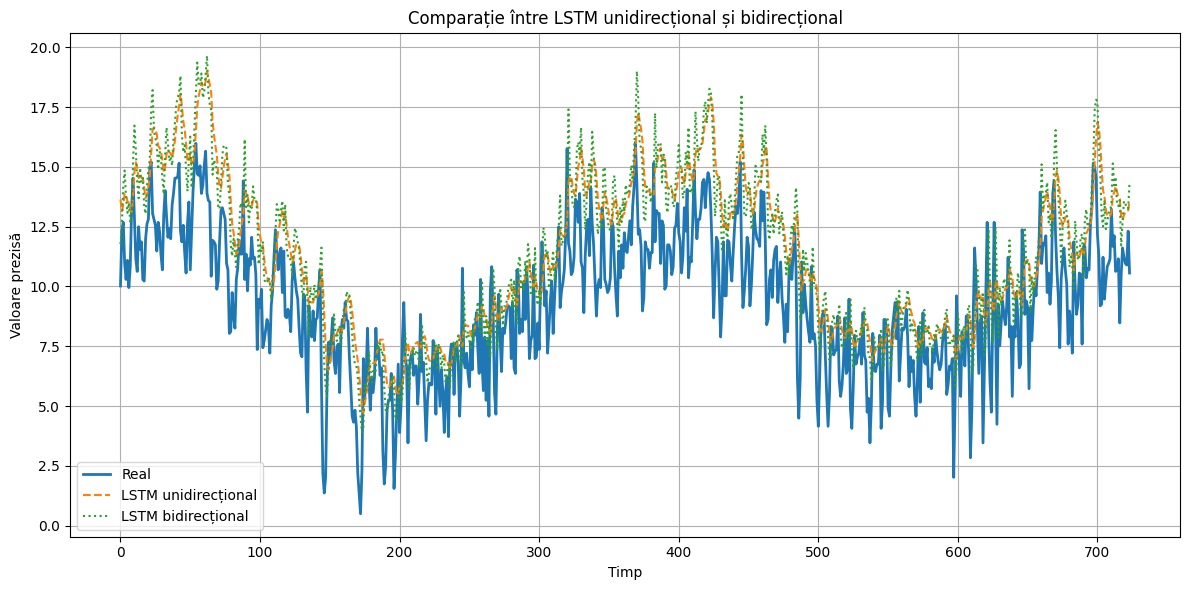

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Model GRU unidirecțional
class LSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super(LSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size , 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.linear(out[:, -1, :])

# Model GRU bidirecțional
class BidirectionalLSTMModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super(BidirectionalLSTMModel, self).__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.linear = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.linear(out[:, -1, :])  # ultimele ieșiri combinate din ambele direcții

# Funcție de antrenare
def train(model, X, Y, epochs=100, lr=0.01):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for epoch in range(epochs):
        model.train()
        out = model(X).squeeze()
        loss = loss_fn(out.view(-1), Y.view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f"[{model.__class__.__name__}] Epoch {epoch} - Loss: {loss.item():.4f}")
    return model

# Inițializare și antrenare
model_uni = LSTMModel()
model_bi = BidirectionalLSTMModel()

model_uni = train(model_uni, X_train, y_train)
model_bi = train(model_bi, X_train, y_train)

# Testare / Predicții
model_uni.eval()
model_bi.eval()
with torch.no_grad():
    pred_uni = model_uni(X_test).cpu().numpy().squeeze()
    pred_bi = model_bi(X_test).cpu().numpy().squeeze()
    pred_uni = np.expm1(pred_uni)
    pred_bi = np.expm1(pred_bi)

# Plot
pred_uni_real = scaler.inverse_transform(pred_uni.reshape(-1, 1)).flatten()
pred_bi_real = scaler.inverse_transform(pred_bi.reshape(-1, 1)).flatten()
y_test_real = scaler.inverse_transform(y_test.cpu().numpy().reshape(-1, 1)).flatten()

plt.figure(figsize=(12, 6))
plt.plot(y_test_real, label="Real", linewidth=2)
plt.plot(pred_uni_real, label="LSTM unidirecțional", linestyle="--")
plt.plot(pred_bi_real, label="LSTM bidirecțional", linestyle=":")
plt.title("Comparație între LSTM unidirecțional și bidirecțional")
plt.xlabel("Timp")
plt.ylabel("Valoare prezisă")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_uni = mean_squared_error(y_test_real, pred_uni_real)
mae_uni = mean_absolute_error(y_test_real, pred_uni_real)
rmse_uni = np.sqrt(mse_uni)
r2_uni = r2_score(y_test_real, pred_uni_real)

print(f"MSE:  {mse_uni:.4f}")
print(f"MAE:  {mae_uni:.4f}")
print(f"RMSE: {rmse_uni:.4f}")
print(f"R²:   {r2_uni:.4f}")
print()

mse_bi = mean_squared_error(y_test_real, pred_bi_real)
mae_bi = mean_absolute_error(y_test_real, pred_bi_real)
rmse_bi = np.sqrt(mse_bi)
r2_bi = r2_score(y_test_real, pred_bi_real)

print(f"MSE:  {mse_bi:.4f}")
print(f"MAE:  {mae_bi:.4f}")
print(f"RMSE: {rmse_bi:.4f}")
print(f"R²:   {r2_bi:.4f}")

MSE:  7.7201
MAE:  2.2602
RMSE: 2.7785
R²:   0.0686

MSE:  7.2708
MAE:  2.2307
RMSE: 2.6964
R²:   0.1228


cuda
[GRUModel] Epoch 0 - Loss: 0.0200
[GRUModel] Epoch 10 - Loss: 0.0119
[GRUModel] Epoch 20 - Loss: 0.0077
[GRUModel] Epoch 30 - Loss: 0.0056
[GRUModel] Epoch 40 - Loss: 0.0049
[GRUModel] Epoch 50 - Loss: 0.0047
[GRUModel] Epoch 60 - Loss: 0.0045
[GRUModel] Epoch 70 - Loss: 0.0044
[GRUModel] Epoch 80 - Loss: 0.0044
[GRUModel] Epoch 90 - Loss: 0.0044
[BidirectionalGRUModel] Epoch 0 - Loss: 0.0817
[BidirectionalGRUModel] Epoch 10 - Loss: 0.0130
[BidirectionalGRUModel] Epoch 20 - Loss: 0.0072
[BidirectionalGRUModel] Epoch 30 - Loss: 0.0054
[BidirectionalGRUModel] Epoch 40 - Loss: 0.0049
[BidirectionalGRUModel] Epoch 50 - Loss: 0.0049
[BidirectionalGRUModel] Epoch 60 - Loss: 0.0047
[BidirectionalGRUModel] Epoch 70 - Loss: 0.0046
[BidirectionalGRUModel] Epoch 80 - Loss: 0.0045
[BidirectionalGRUModel] Epoch 90 - Loss: 0.0045


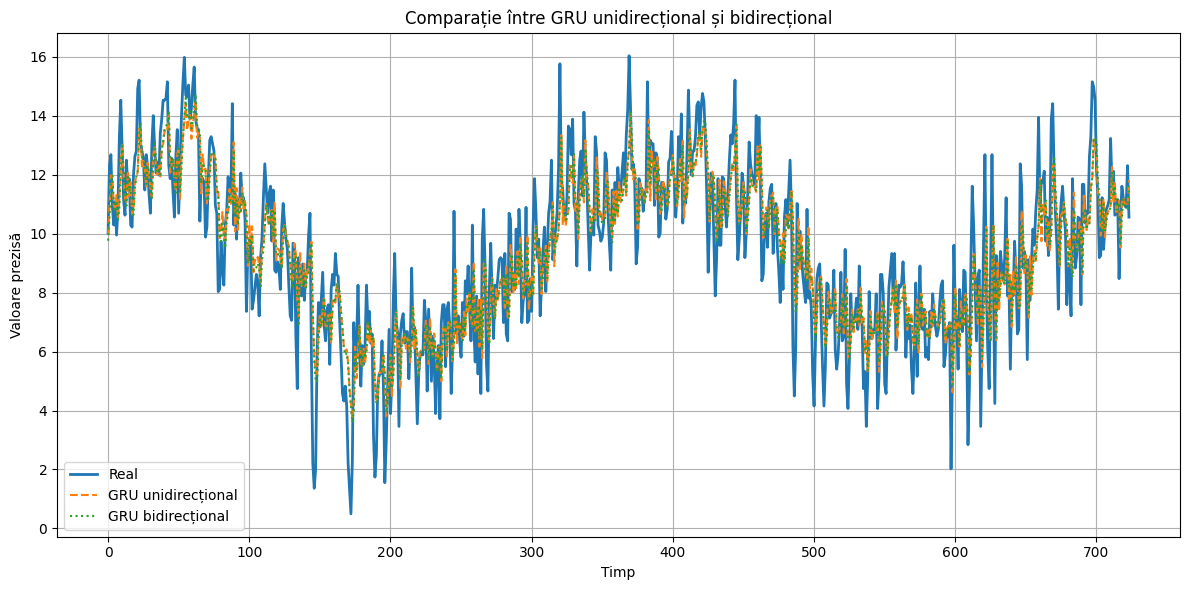

In [ ]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt

# Setări generale
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
# Model GRU unidirecțional
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super(GRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size , 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.linear(out[:, -1, :])

# Model GRU bidirecțional
class BidirectionalGRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=32, num_layers=2):
        super(BidirectionalGRUModel, self).__init__()
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, bidirectional=True)
        self.linear = nn.Linear(hidden_size * 2, 1)

    def forward(self, x):
        out, _ = self.gru(x)
        return self.linear(out[:, -1, :])  # ultimele ieșiri combinate din ambele direcții

# Funcție de antrenare
def train(model, X, Y, epochs=100, lr=0.01):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()
    for epoch in range(epochs):
        model.train()
        out = model(X).squeeze()
        loss = loss_fn(out.view(-1), Y.view(-1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if epoch % 10 == 0:
            print(f"[{model.__class__.__name__}] Epoch {epoch} - Loss: {loss.item():.4f}")
    return model

# Inițializare și antrenare
model_uni = GRUModel()
model_bi = BidirectionalGRUModel()

model_uni = train(model_uni, X_train, y_train)
model_bi = train(model_bi, X_train, y_train)

# Testare / Predicții
model_uni.eval()
model_bi.eval()
with torch.no_grad():
    pred_uni = model_uni(X_test).cpu().numpy().squeeze()
    pred_bi = model_bi(X_test).cpu().numpy().squeeze()

# Plot
pred_uni_real = scaler.inverse_transform(pred_uni.reshape(-1, 1)).flatten()
pred_bi_real = scaler.inverse_transform(pred_bi.reshape(-1, 1)).flatten()
y_test_real = scaler.inverse_transform(y_test.cpu().numpy().reshape(-1, 1)).flatten()

plt.figure(figsize=(12, 6))
plt.plot(y_test_real, label="Real", linewidth=2)
plt.plot(pred_uni_real, label="GRU unidirecțional", linestyle="--")
plt.plot(pred_bi_real, label="GRU bidirecțional", linestyle=":")
plt.title("Comparație între GRU unidirecțional și bidirecțional")
plt.xlabel("Timp")
plt.ylabel("Valoare prezisă")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mse_uni = mean_squared_error(y_test_real, pred_uni_real)
mae_uni = mean_absolute_error(y_test_real, pred_uni_real)
rmse_uni = np.sqrt(mse_uni)
r2_uni = r2_score(y_test_real, pred_uni_real)

print(f"MSE:  {mse_uni:.4f}")
print(f"MAE:  {mae_uni:.4f}")
print(f"RMSE: {rmse_uni:.4f}")
print(f"R²:   {r2_uni:.4f}")
print()

mse_bi = mean_squared_error(y_test_real, pred_bi_real)
mae_bi = mean_absolute_error(y_test_real, pred_bi_real)
rmse_bi = np.sqrt(mse_bi)
r2_bi = r2_score(y_test_real, pred_bi_real)

print("GRU bidirecțional:")
print(f"MSE:  {mse_bi:.4f}")
print(f"MAE:  {mae_bi:.4f}")
print(f"RMSE: {rmse_bi:.4f}")
print(f"R²:   {r2_bi:.4f}")


MSE:  2.4180
MAE:  1.2154
RMSE: 1.5550
R²:   0.7083

GRU bidirecțional:
MSE:  2.4651
MAE:  1.2256
RMSE: 1.5701
R²:   0.7026


In [ ]:
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc

# ---------------------------
# 1) Data: Triplets (anchor, positive, negative) from LFW
# ---------------------------

class LFWTriplet(Dataset):
    def __init__(self, resize=0.5, color=True):
        data = fetch_lfw_people(resize=resize, color=color, funneled=True)
        self.images = data.images.astype(np.float32)
        self.targets = data.target
        self.names = data.target_names

        if not color:
            self.images = self.images[:, None, :, :] / 255.0
        else:
            self.images = np.transpose(self.images, (0,3,1,2)) / 255.0

        self.class_to_indices = {}
        for idx, label in enumerate(self.targets):
            self.class_to_indices.setdefault(label, []).append(idx)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        anchor_img = torch.from_numpy(self.images[idx])
        anchor_label = self.targets[idx]

        # choose positive
        pos_idx = random.choice(self.class_to_indices[anchor_label])
        positive_img = torch.from_numpy(self.images[pos_idx])

        # choose negative
        neg_label = random.choice([l for l in self.class_to_indices.keys() if l != anchor_label])
        neg_idx = random.choice(self.class_to_indices[neg_label])
        negative_img = torch.from_numpy(self.images[neg_idx])

        return anchor_img, positive_img, negative_img

# ---------------------------
# 2) Model: ResNet-18 -> 128-D L2-normalized embedding
# ---------------------------

class ResNetEmbedding(nn.Module):
    def __init__(self, out_dim=128, in_ch=3):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        if in_ch == 1:
            base.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        base.fc = nn.Identity()
        self.base = base
        self.fc = nn.Linear(512, out_dim)

    def forward(self, x):
        x = self.base(x)
        x = self.fc(x)
        return F.normalize(x, p=2, dim=1)

# ---------------------------
# 3) Loss: Triplet
# ---------------------------

class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = torch.norm(anchor - positive, dim=1)
        neg_dist = torch.norm(anchor - negative, dim=1)
        losses = F.relu(pos_dist - neg_dist + self.margin)
        return losses.mean()

# ---------------------------
# 4) Training / Evaluation
# ---------------------------

def train(model, loader, optimizer, criterion, device):
    model.train()
    running = 0.0
    for a,p,n in loader:
        a,p,n = a.to(device), p.to(device), n.to(device)
        optimizer.zero_grad()
        za, zp, zn = model(a), model(p), model(n)
        loss = criterion(za, zp, zn)
        loss.backward()
        optimizer.step()
        running += loss.item() * a.size(0)
    return running / len(loader.dataset)

@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    sims, labels = [], []
    for a,p,n in loader:
        a,p,n = a.to(device), p.to(device), n.to(device)
        za, zp, zn = model(a), model(p), model(n)
        sims.extend(F.cosine_similarity(za, zp).cpu().numpy())
        labels.extend([1]*len(za))
        sims.extend(F.cosine_similarity(za, zn).cpu().numpy())
        labels.extend([0]*len(za))
    sims = np.array(sims)
    labels = np.array(labels)
    fpr, tpr, thresh = roc_curve(labels, sims)
    roc_auc = auc(fpr, tpr)
    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    thr = thresh[idx]
    return float(roc_auc), float(eer), float(thr)

# ---------------------------
# 5) Train in notebook
# ---------------------------

# Hyperparameters (edit as you like)
epochs = 5
batch_size = 64
lr = 1e-3
resize = 0.5
color = True
margin = 1.0
out_file = "resnet_triplet.pth"

# Seed
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_ds = LFWTriplet(resize=resize, color=color)
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)

in_ch = 3 if color else 1
model = ResNetEmbedding(in_ch=in_ch).to(device)
criterion = TripletLoss(margin=margin)
optimizer = torch.optim.Adam(model.parameters(), lr=lr)

best_auc, best_thr = 0.0, None

for epoch in range(1, epochs+1):
    train_loss = train(model, train_loader, optimizer, criterion, device)
    auc_val, eer, thr = evaluate(model, train_loader, device)
    print(f"Epoch {epoch:02d} | loss {train_loss:.4f} | AUC {auc_val:.4f} | EER {eer:.4f} | thr {thr:.3f}")
    if auc_val > best_auc:
        best_auc, best_thr = auc_val, thr
        torch.save({"model": model.state_dict(),
                    "in_ch": in_ch,
                    "thr": thr}, out_file)

print(f"Saved best model to {out_file} with AUC={best_auc:.4f}, thr={best_thr:.3f}")


Epoch 01 | loss 0.3824 | AUC 0.8803 | EER 0.2136 | thr 0.644
Epoch 02 | loss 0.3177 | AUC 0.9184 | EER 0.1693 | thr 0.707
Epoch 03 | loss 0.2762 | AUC 0.9302 | EER 0.1505 | thr 0.631
Epoch 04 | loss 0.2504 | AUC 0.9403 | EER 0.1353 | thr 0.622
Epoch 05 | loss 0.2293 | AUC 0.9425 | EER 0.1373 | thr 0.689
Saved best model to resnet_triplet.pth with AUC=0.9425, thr=0.689


In [ ]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.models as models
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc


# ====================================================
# 1) Dataset with labels for Triplet Mining
# ====================================================
class LFWDataset(Dataset):
    """
    Simple LFW dataset wrapper returning image + label
    """
    def __init__(self, resize=0.5, color=True):
        data = fetch_lfw_people(resize=resize, color=color, funneled=True)
        self.images = data.images.astype(np.float32)
        self.targets = data.target
        self.names = data.target_names

        if not color:
            self.images = self.images[:, None, :, :] / 255.0
        else:
            self.images = np.transpose(self.images, (0, 3, 1, 2)) / 255.0

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return torch.from_numpy(self.images[idx]), self.targets[idx]


# ====================================================
# 2) Model: ResNet-18 -> Embeddings
# ====================================================
class ResNetEmbedding(nn.Module):
    def __init__(self, out_dim=128, in_ch=3):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        if in_ch == 1:
            base.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        base.fc = nn.Identity()
        self.base = base
        self.fc = nn.Linear(512, out_dim)

    def forward(self, x):
        x = self.base(x)
        x = self.fc(x)
        return F.normalize(x, p=2, dim=1)


# ====================================================
# 3) Triplet Loss
# ====================================================
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super().__init__()
        self.margin = margin

    def forward(self, anchor, positive, negative):
        pos_dist = torch.norm(anchor - positive, dim=1)
        neg_dist = torch.norm(anchor - negative, dim=1)
        losses = F.relu(pos_dist - neg_dist + self.margin)
        return losses.mean()


# ====================================================
# 4) Semi-Hard Negative Mining
# ====================================================
def create_semi_hard_triplets(embeddings, labels, margin=0.2):
    """
    Generate semi-hard triplets from embeddings in a batch
    embeddings: (batch, 128)
    labels: (batch,)
    """
    triplets = []
    n = len(embeddings)
    for i in range(n):
        anchor, anchor_label = embeddings[i], labels[i]

        # Find positives
        pos_mask = labels == anchor_label
        pos_indices = torch.where(pos_mask)[0]
        pos_indices = pos_indices[pos_indices != i]
        if len(pos_indices) == 0:
            continue
        pos_idx = random.choice(pos_indices.tolist())
        positive = embeddings[pos_idx]

        # Find negatives
        neg_mask = labels != anchor_label
        neg_indices = torch.where(neg_mask)[0]
        if len(neg_indices) == 0:
            continue
        neg_embeds = embeddings[neg_indices]

        # Similarities
        pos_sim = F.cosine_similarity(anchor.unsqueeze(0), positive.unsqueeze(0)).item()
        sims = F.cosine_similarity(anchor.unsqueeze(0), neg_embeds).squeeze()

        # Semi-hard: sim < pos_sim but close
        mask = (sims < pos_sim) & (sims > pos_sim - margin)
        if mask.any():
            neg_idx = neg_indices[mask][torch.randint(mask.sum(), (1,))]
        else:
            neg_idx = random.choice(neg_indices.tolist())
        negative = embeddings[neg_idx]

        # 🔑 Fix: unsqueeze so everything is (1,128)
        triplets.append((anchor.unsqueeze(0), positive.unsqueeze(0), negative.unsqueeze(0)))

    if len(triplets) == 0:
        return None
    a, p, n = zip(*triplets)
    return torch.cat(a, dim=0), torch.cat(p, dim=0), torch.cat(n, dim=0)



# ====================================================
# 5) Training / Evaluation
# ====================================================
def train_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)

        # Compute embeddings
        embeds = model(imgs)

        # Semi-hard triplets directly from embeddings
        triplets = create_semi_hard_triplets(embeds.cpu(), labels.cpu(), margin=0.2)
        if triplets is None:
            continue
        a, p, n = [x.to(device) for x in triplets]

        optimizer.zero_grad()
        loss = criterion(a, p, n)   # use directly, no model(a)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * len(a)
    return running_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    sims, labels = [], []
    for imgs, lbls in loader:
        imgs = imgs.to(device)
        embeds = model(imgs)

        # Compare all pairs in batch
        for i in range(len(imgs)):
            for j in range(i + 1, len(imgs)):
                sim = F.cosine_similarity(
                    embeds[i].unsqueeze(0), embeds[j].unsqueeze(0)
                ).item()
                sims.append(sim)
                labels.append(int(lbls[i] == lbls[j]))

    sims = np.array(sims)
    labels = np.array(labels)
    fpr, tpr, thresh = roc_curve(labels, sims)
    roc_auc = auc(fpr, tpr)

    fnr = 1 - tpr
    idx = np.nanargmin(np.abs(fnr - fpr))
    eer = (fpr[idx] + fnr[idx]) / 2.0
    thr = thresh[idx]
    return float(roc_auc), float(eer), float(thr)


def plot_losses(train_losses, title="Training Loss"):
    plt.figure(figsize=(8, 5))
    plt.plot(train_losses, marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.grid(True)
    plt.show()


# ====================================================
# 6) Main Training Loop
# ====================================================
def main(epochs=5, batch_size=64, lr=1e-3, resize=0.5, color=True, margin=1.0, out_file="resnet_triplet.pth"):
    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # Dataset & Split
    full_ds = LFWDataset(resize=resize, color=color)
    train_size = int(0.8 * len(full_ds))
    val_size = len(full_ds) - train_size
    train_ds, val_ds = random_split(full_ds, [train_size, val_size])

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    in_ch = 3 if color else 1
    model = ResNetEmbedding(in_ch=in_ch).to(device)
    criterion = TripletLoss(margin=margin)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_auc, best_thr = 0.0, None
    train_losses = []

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        auc_val, eer, thr = evaluate(model, val_loader, device)

        train_losses.append(train_loss)
        print(f"Epoch {epoch:02d} | Loss {train_loss:.4f} | AUC {auc_val:.4f} | EER {eer:.4f} | Thr {thr:.3f}")

        if auc_val > best_auc:
            best_auc, best_thr = auc_val, thr
            torch.save({
                "model": model.state_dict(),
                "in_ch": in_ch,
                "thr": thr
            }, out_file)

    print(f"✅ Best model saved to {out_file} with AUC={best_auc:.4f}, Thr={best_thr:.3f}")
    plot_losses(train_losses)


if __name__ == "__main__":
    main()


RuntimeError: The size of tensor a (6) must match the size of tensor b (128) at non-singleton dimension 1

In [ ]:
from google.colab import files
files.download("resnet_triplet.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import torch
from PIL import Image
import torchvision.transforms as T
from face_verification_scratch import Siamese  # import your model class
from facenet_pytorch import MTCNN

# Load trained model checkpoint
ckpt = torch.load("resnet_triplet.pth", map_location="cpu")
mtcnn = MTCNN(image_size=125)
model = Siamese(in_ch=ckpt["in_ch"])
model.load_state_dict(ckpt["model"])
model.eval()
sim_threshold = ckpt["sim_threshold"]

# Preprocessing: match training setup
transform = T.Compose([
    T.Grayscale(),             # model trained on grayscale
    T.Resize((125, 94)),       # match LFW dimensions
    T.ToTensor()
])

def preprocess(frame):
    pil_img = Image.fromarray(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    face = mtcnn(pil_img)
    if face is None:
        raise ValueError("No face detected")
    # Convert to grayscale (1 channel) to match training
    face_gray = face.mean(dim=0, keepdim=True)  # average RGB → (1,H,W)
    return face_gray.unsqueeze(0)  # (1,1,125,125)


def capture_face(window_name="Capture"):
    cap = cv2.VideoCapture(0)
    print("Press SPACE to capture a photo, ESC to exit")
    img = None
    while True:
        ret, frame = cap.read()
        if not ret:
            continue
        cv2.imshow(window_name, frame)
        key = cv2.waitKey(1)
        if key == 27:  # ESC
            break
        elif key == 32:  # SPACE
            img = frame.copy()
            break
    cap.release()
    cv2.destroyAllWindows()
    return img

def verify_from_camera():
    print("Capture first face...")
    frame1 = capture_face("First Face")
    print("Capture second face...")
    frame2 = capture_face("Second Face")

    if frame1 is None or frame2 is None:
        print("No photos captured.")
        return

    x1, x2 = preprocess(frame1), preprocess(frame2)

    with torch.no_grad():
        z1, z2 = model(x1, x2)
        sim = torch.nn.functional.cosine_similarity(z1, z2).item()

    same = sim >= sim_threshold
    print(f"Same person? {same} | sim={sim:.3f} | threshold={sim_threshold:.3f}")

if __name__ == "__main__":
    verify_from_camera()


ModuleNotFoundError: No module named 'face_verification_scratch'